In [2]:
import numpy as np
from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

验证Stretch constraint的gradient的误差

In [13]:
pos0 = np.loadtxt("node_pos_E1.e4.csv", delimiter=",")
pos1 = np.loadtxt("node_pos_E1.e4-1.e2.csv", delimiter=",")

diff_param = (pos0 - pos1) / 1.e2

dparam = np.loadtxt("dq_dw_stretch.csv", delimiter=",").reshape(-1, 3)

error_abs = np.abs(diff_param[4:] - dparam[4:])
error_rel = np.sum(error_abs, axis=1) / (np.sum(np.abs(diff_param[4:]), axis=1) + 1.e-12)

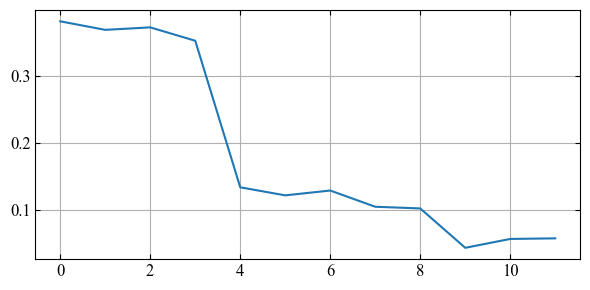

In [15]:
fig = plt.figure(figsize=(6, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

eps = 1.e-9
axs_error = fig.add_subplot(gs[0, 0])
axs_error.plot(error_rel, label=r"$\frac{\partial q}{\partial w}$")

axs_error.tick_params(axis='both', which='major', labelsize=12, direction='in', top=True, right=True)
axs_error.grid(True)
plt.tight_layout()

In [28]:
print(np.sum(diff_param))
print(np.sum(dparam))

-7.002782884260503e-06
-7.9122367920022e-06


验证Bending constraint的gradient误差；虽然误差很大，但是大小关系是对应的

In [20]:
pos0 = np.loadtxt("node_pos_bend1.csv", delimiter=",")
pos1 = np.loadtxt("node_pos_bend1-0.01.csv", delimiter=",")

diff_param = (pos0 - pos1) / 0.01

dparam = np.loadtxt("dq_dw_bend.csv", delimiter=",").reshape(-1, 3)

error_abs = np.abs(diff_param[5:20] - dparam[5:20])
error_rel = np.sum(error_abs, axis=1) / (np.sum(np.abs(diff_param[5:20]), axis=1) + 1.e-12)

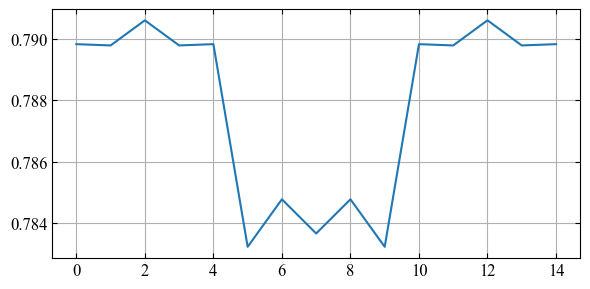

In [21]:
fig = plt.figure(figsize=(6, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

eps = 1.e-9
axs_error = fig.add_subplot(gs[0, 0])
axs_error.plot(error_rel, label=r"$\frac{\partial q}{\partial w}$")

axs_error.tick_params(axis='both', which='major', labelsize=12, direction='in', top=True, right=True)
axs_error.grid(True)
plt.tight_layout()